# PRODUCT REVIEWS PROJECT

##### 1. Aggregated customer feedback from multiple sources.

##### 2. Classified reviews into positive, negative, or neutral to help improve products and services.

##### 3. Clustered products into 4–6 categories for simplified browsing.

### STEP 1 : IMPORTING LIBRARIES


In [1]:
# ========================================
# IMPORTS AND DATA LOADING
# ========================================
import pandas as pd
import matplotlib.pyplot as plt
import string
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.ensemble import RandomForestClassifier
import nltk
import nltk
import re



from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np

from sklearn.svm import SVC
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

2025-11-14 10:59:00.140409: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[nltk_data] Downloading package punkt to /home/georg/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/georg/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/georg/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /home/georg/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/georg/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/georg/nltk_data...
[nltk_data]   P

True

### STEP 2 : LOADING THE DATASET

In [2]:
# Load dataset
df = pd.read_csv('data/1429_1.csv')

/tmp/ipykernel_19401/2943226125.py:2: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/1429_1.csv')


### STEP 3: EXPLORATORY DATA ANALYSIS (EDA)

##### SUB STEP 1: REVIEWING THE COLUMN

In [3]:
# ========================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ========================================
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst few rows:")
print(df.head())

Dataset shape: (34660, 21)
Columns: ['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer', 'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen', 'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username']

First few rows:
                     id                                               name  \
0  AVqkIhwDv8e3D1O-lebb  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...   
1  AVqkIhwDv8e3D1O-lebb  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...   
2  AVqkIhwDv8e3D1O-lebb  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...   
3  AVqkIhwDv8e3D1O-lebb  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...   
4  AVqkIhwDv8e3D1O-lebb  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...   

        asins   brand                                         categories  \
0  B01AHB9CN2  Amazon  Electronics,iPad & Tablets,All T

##### SUB STEP 2: ANALYZING THE COLUMN RATING

In [4]:
# --- Ratings ---
print("REVIEW TEXT (first 3 examples):")
for i in range(3):
    print(f"{i+1}. Rating: {df['reviews.rating'].iloc[i]} - Text: {df['reviews.text'].iloc[i][:100]}...")

print(f"\nRATING DISTRIBUTION:")
print(df['reviews.rating'].value_counts().sort_index())

print(f"\nRating Statistics:")
print(df['reviews.rating'].describe())

REVIEW TEXT (first 3 examples):
1. Rating: 5.0 - Text: This product so far has not disappointed. My children love to use it and I like the ability to monit...
2. Rating: 5.0 - Text: great for beginner or experienced person. Bought as a gift and she loves it...
3. Rating: 5.0 - Text: Inexpensive tablet for him to use and learn on, step up from the NABI. He was thrilled with it, lear...

RATING DISTRIBUTION:
reviews.rating
1.0      410
2.0      402
3.0     1499
4.0     8541
5.0    23775
Name: count, dtype: int64

Rating Statistics:
count    34627.000000
mean         4.584573
std          0.735653
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: reviews.rating, dtype: float64


##### SUB STEP 3: PLOTTINGING GRAPH FOR THE COLUMN RATING

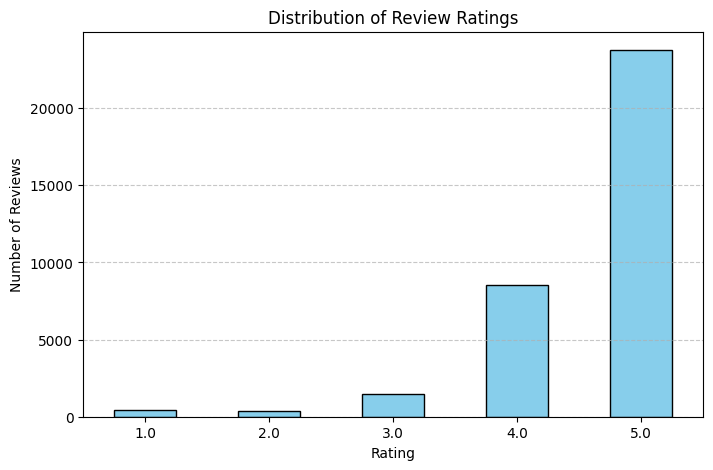

In [5]:
# Bar chart for ratings
rating_counts = df['reviews.rating'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
rating_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Review Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### STEP 4: DATA CLEANING AND PREPROCESSING

In [6]:
# ========================================
# NLP PREPROCESSING
# ========================================
def preprocess_text(text):
    """Clean and preprocess review text with lemmatization and stemming"""
    
    # --- Ensure input is string and clean hidden/unwanted characters ---
    if not isinstance(text, str):
        text = str(text)
    text = text.replace('\ufeff', '')        # Remove BOM characters
    text = text.strip()                      # Remove leading/trailing spaces
    text = re.sub(r'\s+', ' ', text)        # Normalize multiple spaces
    
    # --- Tokenization ---
    tokens = word_tokenize(text.lower())
    
    # --- Remove stopwords ---
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words]
    
    # --- Remove punctuation and numbers ---
    tokens = [re.sub(r'[^a-zA-Z]', '', t) for t in tokens]
    tokens = [t for t in tokens if t]  # Remove empty strings
    
    # --- Lemmatization ---
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    
    # --- Stemming ---
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(t) for t in tokens]
    
    return ' '.join(tokens)

In [7]:
# Apply preprocessing

df['clean_text'] = df['reviews.text'].apply(preprocess_text)

# --- Inspect cleaned text samples ---
print("\nSAMPLE CLEANED TEXT (first 3 examples):")
for i in range(3):
    print(f"{i+1}. {df['clean_text'].iloc[i][:150]}...")




SAMPLE CLEANED TEXT (first 3 examples):
1. product far disappoint child love use like abil monitor control content see eas...
2. great beginn experienc person bought gift love...
3. inexpens tablet use learn step nabi thrill learn skype alreadi...


In [8]:
# Bag-of-Words (optional)
vectorizer = CountVectorizer(max_features=1000)
bow_matrix = vectorizer.fit_transform(df['clean_text'])
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=vectorizer.get_feature_names_out())
print("\nBag of Words shape:", bow_df.shape)
print("Example BoW columns:", bow_df.columns[:10].tolist())


Bag of Words shape: (34660, 1000)
Example BoW columns: ['abil', 'abl', 'absolut', 'access', 'account', 'across', 'activ', 'actual', 'ad', 'adapt']


### STEP 5: SENTIMENT ANALYSIS MODELING

##### SUB STEP 1. SENTIMENT MODEL LABELING

In [9]:
# ========================================
# SENTIMENT LABEL CREATION
# ========================================
def rating_to_sentiment(rating):
    if pd.isna(rating):
        return None
    elif rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

##### SUB STEP 2. SENTIMENT MODEL DATA FRAME CREATION AND PLOTTING GRAPH

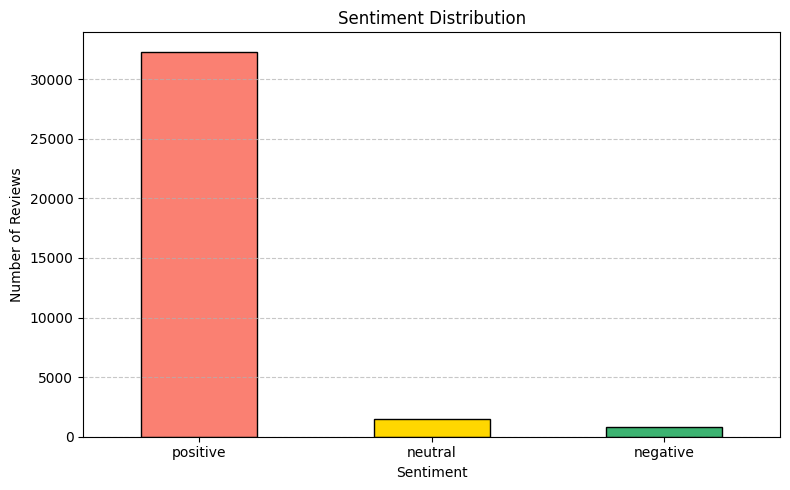

In [10]:
df['sentiment'] = df['reviews.rating'].apply(rating_to_sentiment)

# Plot sentiment distribution
sentiment_dist = df['sentiment'].value_counts()
plt.figure(figsize=(8, 5))
sentiment_dist.plot(kind='bar', color=['salmon', 'gold', 'mediumseagreen'], edgecolor='black')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### SUB STEP 3. SENTIMENT MODEL BUILDING - "RATING COLUMN"

Checking for None values in sentiment data...
Total None values in sentiment: 33
Sentiment value counts:
sentiment
positive    32316
neutral      1499
negative      812
None           33
Name: count, dtype: int64

After cleaning:
Remaining samples: 34627
Sentiment distribution:
sentiment
positive    32316
neutral      1499
negative      812
Name: count, dtype: int64

Training set size: 27701
Validation set size: 6926

Vectorization complete:
Training features shape: (27701, 1000)
Validation features shape: (6926, 1000)

=== SENTIMENT CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    negative       0.32      0.43      0.37       162
     neutral       0.24      0.24      0.24       300
    positive       0.96      0.95      0.96      6464

    accuracy                           0.91      6926
   macro avg       0.51      0.54      0.52      6926
weighted avg       0.91      0.91      0.91      6926


Vectorization complete:
Training features shape: (27

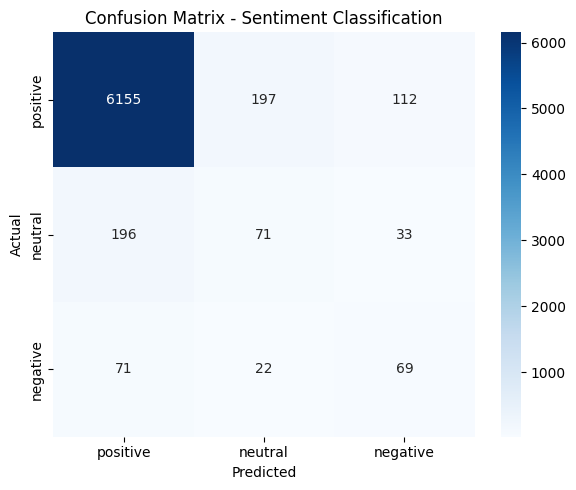


=== ADDITIONAL DIAGNOSTICS ===
Unique values in y_test: ['negative' 'neutral' 'positive']
Unique values in y_pred: ['negative' 'neutral' 'positive']
Validation set class distribution:
sentiment
positive    6464
neutral      300
negative     162
Name: count, dtype: int64


In [11]:
# ========================================
# MODEL BUILDING
# Task 1: Sentiment Classification
# ========================================

# First, check for None values in the target variable
print("Checking for None values in sentiment data...")
print(f"Total None values in sentiment: {df['sentiment'].isna().sum()}")
print(f"Sentiment value counts:")
print(df['sentiment'].value_counts(dropna=False))

# Clean the data before splitting
df_clean = df.dropna(subset=['sentiment', 'clean_text']).copy()
df_clean = df_clean[df_clean['sentiment'].notna()]

print(f"\nAfter cleaning:")
print(f"Remaining samples: {len(df_clean)}")
print(f"Sentiment distribution:")
print(df_clean['sentiment'].value_counts())

# Split the cleaned data
X_train, X_test, y_train, y_test = train_test_split(
    df_clean['clean_text'], 
    df_clean['sentiment'], 
    test_size=0.2, 
    random_state=42,
    stratify=df_clean['sentiment']  # Maintain class distribution
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Validation set size: {len(X_test)}")

# Vectorize the text data
vectorizer = CountVectorizer(max_features=1000)
X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)

print(f"\nVectorization complete:")
print(f"Training features shape: {X_train_bow.shape}")
print(f"Validation features shape: {X_test_bow.shape}")

# Train the model
model = MultinomialNB()
model.fit(X_train_bow, y_train)

# Make predictions
y_pred = model.predict(X_test_bow)

print("\n=== SENTIMENT CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['positive', 'neutral', 'negative'])

# Plot the confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['positive', 'neutral', 'negative'], 
            yticklabels=['positive', 'neutral', 'negative'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Sentiment Classification')
plt.tight_layout()
plt.show()

# Additional diagnostics
print("\n=== ADDITIONAL DIAGNOSTICS ===")
print(f"Unique values in y_test: {np.unique(y_test)}")
print(f"Unique values in y_pred: {np.unique(y_pred)}")
print(f"Validation set class distribution:")
print(pd.Series(y_test).value_counts())

##### SUB STEP 3. SENTIMENT MODEL BUILDING - "REVIEW.TEXT COLUMN"

In [12]:
# ========================================
# CLEAN DATA
# ========================================
df['clean_text'] = df['reviews.text'].astype(str).apply(preprocess_text)

# Drop rows where sentiment is missing or invalid
df = df[df['sentiment'].notnull()]
df = df[df['sentiment'].isin(['positive', 'neutral', 'negative'])]

# ========================================
# BAG-OF-WORDS & SPLIT DATA
# ========================================
vectorizer = CountVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['clean_text'])
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [13]:
df['clean_text'] = df['reviews.text'].astype(str).apply(preprocess_text)

# ========================================
# BAG-OF-WORDS & SPLIT DATA
# ========================================
vectorizer = CountVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['clean_text'])
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

=== SENTIMENT CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    negative       0.32      0.43      0.37       162
     neutral       0.25      0.25      0.25       300
    positive       0.96      0.95      0.96      6464

    accuracy                           0.91      6926
   macro avg       0.51      0.54      0.52      6926
weighted avg       0.91      0.91      0.91      6926

MultinomialNB Training Accuracy: 0.9198
MultinomialNB Validation Accuracy: 0.9089


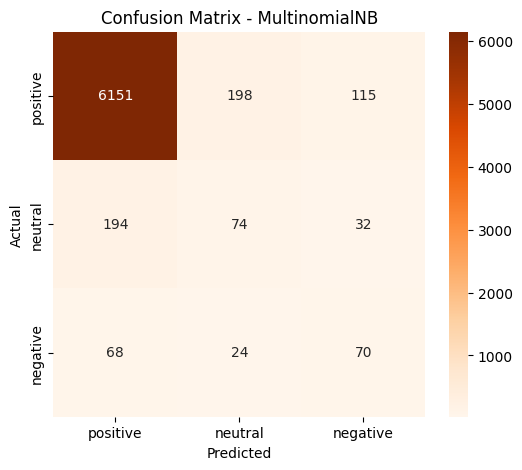

In [14]:
# ========================================
# TRAIN MULTINOMIAL NAIVE BAYES
# ========================================
model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("=== SENTIMENT CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

# Training accuracy
train_acc_nb = model.score(X_train, y_train)
print(f"MultinomialNB Training Accuracy: {train_acc_nb:.4f}")

# Validation (test) accuracy
val_acc_nb = model.score(X_test, y_test)
print(f"MultinomialNB Validation Accuracy: {val_acc_nb:.4f}")

# Confusion matrix with different color
cm_nb = confusion_matrix(y_test, y_pred, labels=['positive', 'neutral', 'negative'])
plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges', xticklabels=['positive', 'neutral', 'negative'], yticklabels=['positive', 'neutral', 'negative'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - MultinomialNB')
plt.show()





### STEP 5: SENTIMENT ANALYSIS MODELING USING RANDOM FOREST

In [15]:
# ========================================
# PREPROCESS TEXT
# ========================================
X_rf = vectorizer.fit_transform(df['clean_text'])
y_rf = df['sentiment']

X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42, stratify=y_rf)

df['clean_text'] = df['reviews.text'].astype(str).apply(preprocess_text)

=== SENTIMENT CLASSIFICATION REPORT RANDOM FOREST===
              precision    recall  f1-score   support

    negative       0.57      0.07      0.13       162
     neutral       0.12      0.00      0.01       300
    positive       0.94      1.00      0.97      6464

    accuracy                           0.93      6926
   macro avg       0.54      0.36      0.37      6926
weighted avg       0.89      0.93      0.90      6926

Random Forest Training Accuracy: 0.9998
Random Forest Validation Accuracy: 0.9333
Random Forest Training Accuracy: 0.9998
Random Forest Validation Accuracy: 0.9333


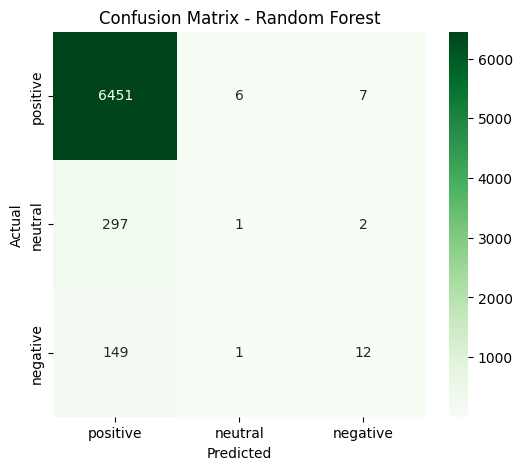

In [16]:
# ========================================
# TRAIN RANDOM FOREST CLASSIFIER
# ========================================
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_rf_train, y_rf_train)
y_rf_pred = rf_model.predict(X_rf_test)

print("=== SENTIMENT CLASSIFICATION REPORT RANDOM FOREST===")
print(classification_report(y_rf_test, y_rf_pred))

# Training accuracy
train_acc_rf = rf_model.score(X_rf_train, y_rf_train)
print(f"Random Forest Training Accuracy: {train_acc_rf:.4f}")

# Validation (test) accuracy
val_acc_rf = rf_model.score(X_rf_test, y_rf_test)
print(f"Random Forest Validation Accuracy: {val_acc_rf:.4f}")

# Confusion matrix with different color
cm_rf = confusion_matrix(y_rf_test, y_rf_pred, labels=['positive', 'neutral', 'negative'])
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=['positive', 'neutral', 'negative'], yticklabels=['positive', 'neutral', 'negative'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

#### STEP 5 : CREATING SENTIMENT ANALYSIS MODEL FOR SVM (SUPPORT VECTOR MACHINE)

In [17]:
# ========================================
# PREPROCESS TEXT FOR SVM
# ========================================
df['clean_text_svm'] = df['reviews.text'].astype(str).apply(preprocess_text)

In [18]:
# ========================================
# BAG-OF-WORDS & SPLIT DATA FOR SVM
# ========================================
vectorizer_svm = CountVectorizer(max_features=1000)
X_svm = vectorizer_svm.fit_transform(df['clean_text_svm'])
y_svm = df['sentiment']

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_svm, y_svm, test_size=0.2, random_state=42, stratify=y_svm
)


=== SVM SENTIMENT CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    negative       0.42      0.31      0.36       162
     neutral       0.18      0.02      0.03       300
    positive       0.94      0.99      0.97      6464

    accuracy                           0.93      6926
   macro avg       0.52      0.44      0.45      6926
weighted avg       0.90      0.93      0.91      6926

SVM Training Accuracy: 0.9496
SVM Training Accuracy: 0.9496
SVM Validation Accuracy: 0.9327
SVM Validation Accuracy: 0.9327


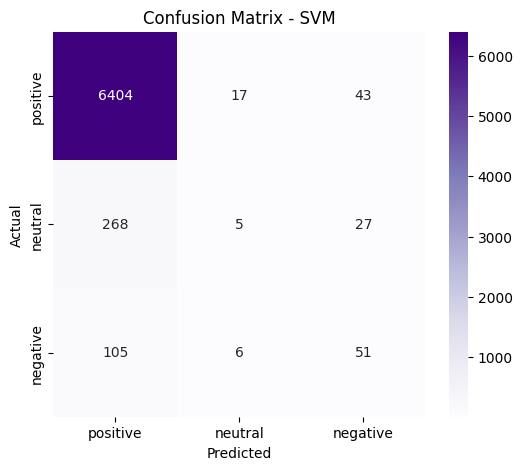

In [19]:
# ========================================
# TRAIN SVM CLASSIFIER
# ========================================
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_svm, y_train_svm)
y_pred_svm = svm_model.predict(X_test_svm)

print("=== SVM SENTIMENT CLASSIFICATION REPORT ===")
print(classification_report(y_test_svm, y_pred_svm))

# Training accuracy
train_acc_svm = svm_model.score(X_train_svm, y_train_svm)
print(f"SVM Training Accuracy: {train_acc_svm:.4f}")

# Validation (test) accuracy
val_acc_svm = svm_model.score(X_test_svm, y_test_svm)
print(f"SVM Validation Accuracy: {val_acc_svm:.4f}")

# Confusion matrix with different color
cm_svm = confusion_matrix(y_test_svm, y_pred_svm, labels=['positive', 'neutral', 'negative'])
plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', xticklabels=['positive', 'neutral', 'negative'], yticklabels=['positive', 'neutral', 'negative'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')
plt.show()

#### STEP 6 : LSTM PIPELINE (Deep Learning with Keras)

In [20]:
# ========================================
# PREPROCESS TEXT FOR LSTM
# ========================================
df['clean_text_lstm'] = df['reviews.text'].astype(str).apply(preprocess_text)

In [21]:
# ========================================
# TOKENIZE & PAD SEQUENCES
# ========================================
MAX_WORDS = 5000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text_lstm'])

X_lstm = tokenizer.texts_to_sequences(df['clean_text_lstm'])
X_lstm = pad_sequences(X_lstm, maxlen=MAX_LEN, padding='post', truncating='post')

In [22]:
# ========================================
# ENCODE LABELS
# ========================================
le = LabelEncoder()
y_lstm = le.fit_transform(df['sentiment'])

In [23]:
# ========================================
# SPLIT DATA
# ========================================
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    X_lstm, y_lstm, test_size=0.2, random_state=42, stratify=y_lstm
)


# ========================================
# BUILD LSTM MODEL
# ========================================
model_lstm = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN),
    # Use non-cuDNN implementation by enabling recurrent_dropout (CPU-friendly)
    LSTM(64, return_sequences=False, recurrent_dropout=0.2),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(len(np.unique(y_lstm)), activation='softmax')
])

model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

/mnt/c/Users/Georg/ownCloud/Dokumente/Ironhack/.venv_acr/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1763114576.766307   19401 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6073 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


In [24]:
# ========================================
# TRAIN LSTM
# ========================================
history = model_lstm.fit(X_train_lstm, y_train_lstm, validation_split=0.1, epochs=1, batch_size=32)

780/780 ━━━━━━━━━━━━━━━━━━━━ 518s 657ms/step - accuracy: 0.9309 - loss: 0.3102 - val_accuracy: 0.9358 - val_loss: 0.2802
780/780 ━━━━━━━━━━━━━━━━━━━━ 518s 657ms/step - accuracy: 0.9309 - loss: 0.3102 - val_accuracy: 0.9358 - val_loss: 0.2802


217/217 ━━━━━━━━━━━━━━━━━━━━ 31s 140ms/step
217/217 ━━━━━━━━━━━━━━━━━━━━ 31s 140ms/step
=== LSTM SENTIMENT CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       162
     neutral       0.00      0.00      0.00       300
    positive       0.93      1.00      0.97      6464

    accuracy                           0.93      6926
   macro avg       0.31      0.33      0.32      6926
weighted avg       0.87      0.93      0.90      6926

LSTM Training Accuracy (final epoch): 0.9309
LSTM Validation Accuracy (final epoch): 0.9358
=== LSTM SENTIMENT CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       162
     neutral       0.00      0.00      0.00       300
    positive       0.93      1.00      0.97      6464

    accuracy                           0.93      6926
   macro avg       0.31      0.33      0.32      6926
weighted avg       0.87

/mnt/c/Users/Georg/ownCloud/Dokumente/Ironhack/.venv_acr/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/c/Users/Georg/ownCloud/Dokumente/Ironhack/.venv_acr/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/c/Users/Georg/ownCloud/Dokumente/Ironhack/.venv_acr/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

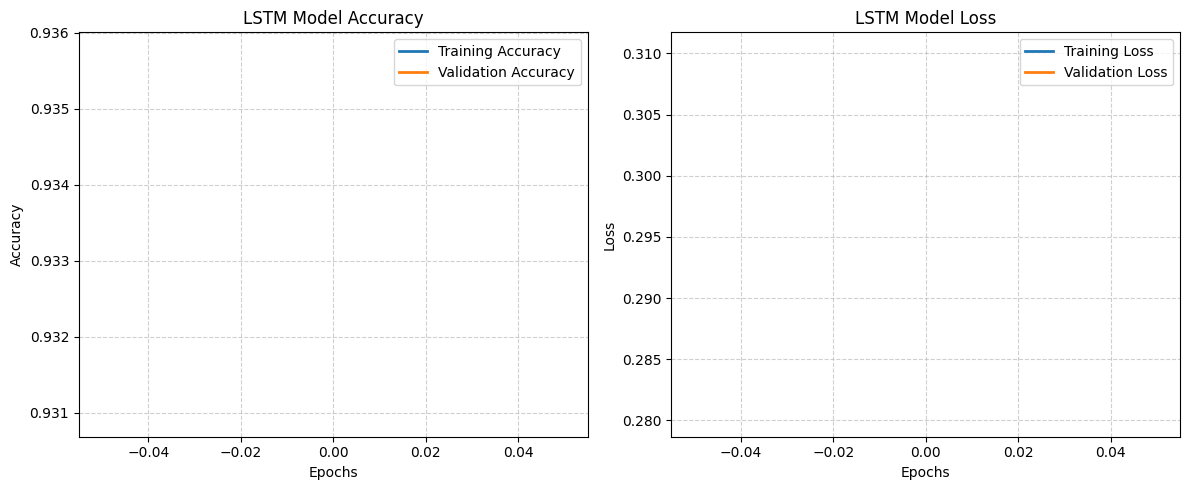

In [25]:
# ========================================
# EVALUATE LSTM
# ========================================
y_pred_lstm = np.argmax(model_lstm.predict(X_test_lstm), axis=1)
print("=== LSTM SENTIMENT CLASSIFICATION REPORT ===")
print(classification_report(y_test_lstm, y_pred_lstm, target_names=le.classes_))

# ========================================
# PLOT TRAINING HISTORY (ACCURACY & LOSS)
# ========================================
plt.figure(figsize=(12, 5))

# ---- Accuracy plot ----
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
final_train_acc_lstm = history.history['accuracy'][-1]
final_val_acc_lstm = history.history['val_accuracy'][-1]
print(f"LSTM Training Accuracy (final epoch): {final_train_acc_lstm:.4f}")
print(f"LSTM Validation Accuracy (final epoch): {final_val_acc_lstm:.4f}")
plt.title('LSTM Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# ---- Loss plot ----
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('LSTM Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()



In [ ]:
# ========================================
# GENERATE SENTIMENT PREDICTIONS + CONFIDENCE (FOR ENTIRE DATASET)
# ========================================

# 1Predict sentiment for all samples
all_predicted_sentiment = svm_model.predict(X_svm)

# Get probabilities (retrain with probability=True if not enabled)
# NOTE: probability=True requires retraining because SVC without it can't predict_proba()
# So let's check and handle that:

if not hasattr(svm_model, "predict_proba"):
    print("\Your current SVM model does not support probability estimates (predict_proba).")
    print("Retraining with probability=True to compute confidence scores...")
    
    from sklearn.svm import SVC
    svm_model = SVC(kernel='linear', probability=True, random_state=42)
    svm_model.fit(X_train_svm, y_train_svm)
    all_predicted_sentiment = svm_model.predict(X_svm)

# Now get probabilities
all_probabilities = svm_model.predict_proba(X_svm)

# Compute confidence scores (probability of the predicted class)
confidence_scores = []
class_labels = svm_model.classes_

for i, pred_sentiment in enumerate(all_predicted_sentiment):
    predicted_class_index = list(class_labels).index(pred_sentiment)
    confidence = all_probabilities[i, predicted_class_index]
    confidence_scores.append(confidence)

# Create final DataFrame
results_df = pd.DataFrame({
    'product_id': df['id'] if 'id' in df.columns else df.index,
    'reviews.text': df['reviews.text'],
    'rating': df['reviews.rating'] if 'reviews.rating' in df.columns else None,
    'original_sentiment_from_rating': df['sentiment'],
    'predicted_sentiment_SVM': all_predicted_sentiment,
    'prediction_confidence': confidence_scores
})

#Export to CSV
output_filename = 'data/product_reviews_sentiment_and_confidence_SVM.csv'
results_df.to_csv(output_filename, index=False)

print(f"\n✅ Successfully generated '{output_filename}' with SVM sentiment and confidence scores.")
print("Preview of generated CSV (first 5 rows):")
print(results_df.head())


\Your current SVM model does not support probability estimates (predict_proba).
Retraining with probability=True to compute confidence scores...

✅ Successfully generated 'data/product_reviews_sentiment_and_confidence_SVM.csv' with SVM sentiment and confidence scores.
Preview of generated CSV (first 5 rows):
             product_id                                       reviews.text  \
0  AVqkIhwDv8e3D1O-lebb  This product so far has not disappointed. My c...   
1  AVqkIhwDv8e3D1O-lebb  great for beginner or experienced person. Boug...   
2  AVqkIhwDv8e3D1O-lebb  Inexpensive tablet for him to use and learn on...   
3  AVqkIhwDv8e3D1O-lebb  I've had my Fire HD 8 two weeks now and I love...   
4  AVqkIhwDv8e3D1O-lebb  I bought this for my grand daughter when she c...   

   rating original_sentiment_from_rating predicted_sentiment_SVM  \
0     5.0                       positive                positive   
1     5.0                       positive                positive   
2     5.0        